In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np
from math import radians, sin, cos, sqrt, atan2


In [2]:
product_category_translation = pd.read_csv('product_category_name_translation.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
geolocation= pd.read_csv('olist_geolocation_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

## Data Preparation


In [3]:
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], errors="coerce")
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"], errors="coerce")


In [4]:
orders = orders[
    orders['order_status'] == 'delivered'
].copy()

In [5]:
orders.shape

(96478, 8)

In [6]:
# Delivery time
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# Delay
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# Process stages
orders['approval_time'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.days
orders['shipping_time'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.days
orders['carrier_time'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.days

In [7]:
def segment(days):
    if days <= 0:
        return "On time / Early"
    elif  days <= 7:
        return "Average Week"
    elif days <= 30:
        return "Average Month"
    else:
        return "More Than Month"

orders['delay_segment'] = orders['delay'].apply(segment)

## On-Time Delivery Performance

In [8]:
total_num_orders=orders.shape[0]

late_orders = orders[orders['delay'] > 0]
on_time_orders = orders[orders['delay']<= 0]

num_on_time_orders=(orders['delay']<=0).sum()
num_delay_orders=(orders['delay']>0).sum()


on_time_rate=(num_on_time_orders/total_num_orders)*100
late_rate =(num_delay_orders/total_num_orders)*100

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Delay Delivery Rate: {late_rate :.2f}%")


On-Time Delivery Rate: 93.22%
Delay Delivery Rate: 6.77%


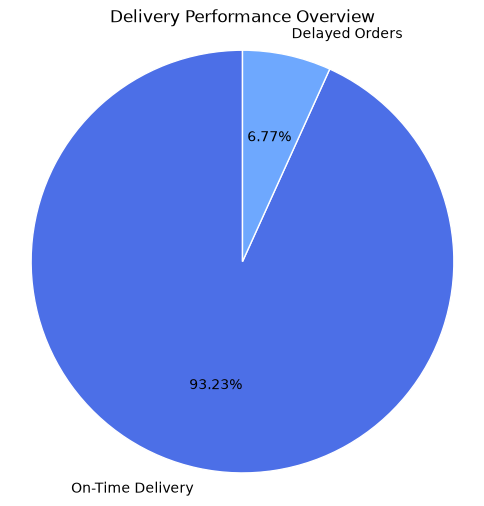

In [35]:
import matplotlib.pyplot as plt

labels = ['On-Time Delivery', 'Delayed Orders']
sizes = [93.22, 6.77]

colors = ['#4C6FE7', '#6EA8FE']  # Blue, Light Gray

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    radius=0.8,
    wedgeprops={'edgecolor': 'white'}
)

ax.set_title("Delivery Performance Overview")
ax.axis('equal')

plt.show()

## Distribution of Delay Days


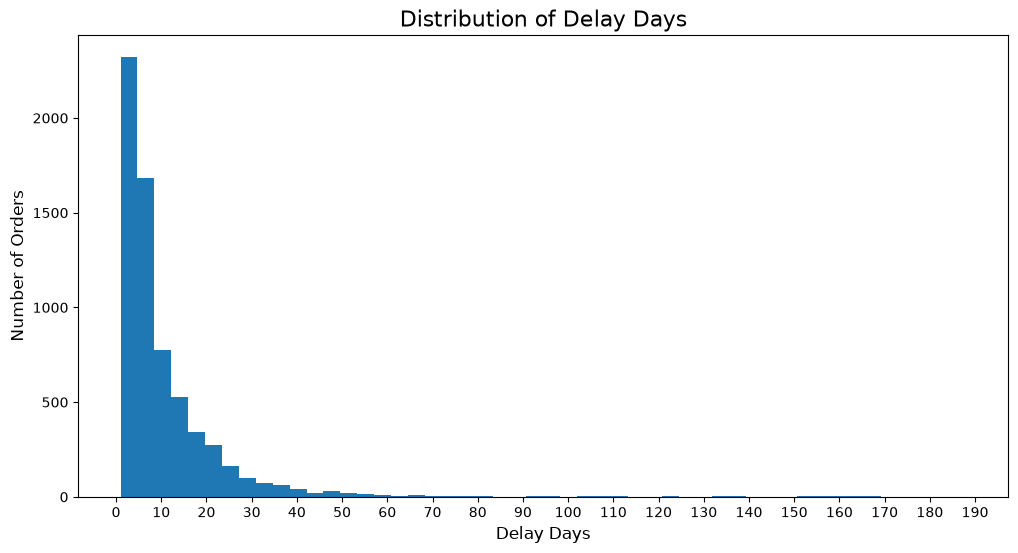

In [10]:
plt.figure(figsize=(12, 6))  

plt.hist(late_orders['delay'], bins=50)

plt.title("Distribution of Delay Days", fontsize=16)
plt.xlabel("Delay Days", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(np.arange(0, late_orders['delay'].max() + 10, 10))

plt.show()

## Actual vs. Estimated Delivery Time

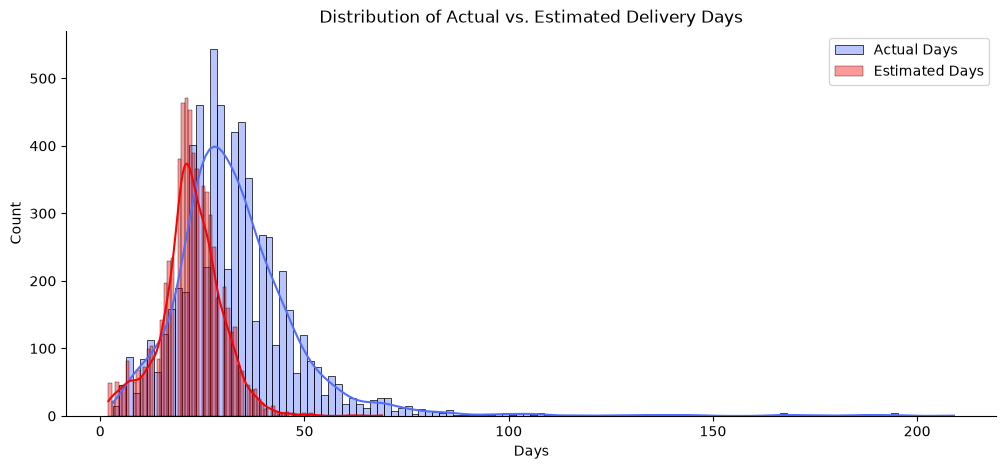

In [11]:
plt.figure(figsize=(12, 5))
late_orders["actual_days"] = (late_orders["order_delivered_customer_date"] - late_orders["order_purchase_timestamp"]).dt.days
late_orders["estimated_days"] = (late_orders["order_estimated_delivery_date"] - late_orders["order_purchase_timestamp"]).dt.days
sns.histplot(late_orders["actual_days"], color="#516efe", label="Actual Days", kde=True, alpha=0.4)
sns.histplot(late_orders["estimated_days"], color="#ff0000", label="Estimated Days", kde=True, alpha=0.4)
sns.despine(right=True, top=True)
plt.title("Distribution of Actual vs. Estimated Delivery Days")
plt.xlabel("Days")
plt.legend()
plt.savefig("distribution_plot.pdf", bbox_inches='tight')
plt.show()

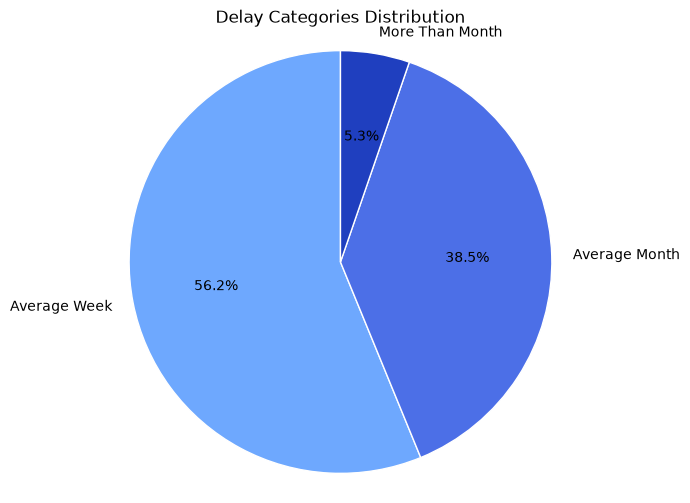

In [34]:
order = ["Average Week", "Average Month", "More Than Month"]
data = late_orders["delay_segment"].value_counts().reindex(order)

colors = ['#6EA8FE', '#4C6FE7', '#1F3FBF']   # Light Blue, Blue, Dark Blue

plt.figure(figsize=(6,6))
plt.pie(
    data.values,
    labels=data.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Delay Categories Distribution")
plt.axis('equal')
plt.show()

##  Average Time Across Delivery Stages

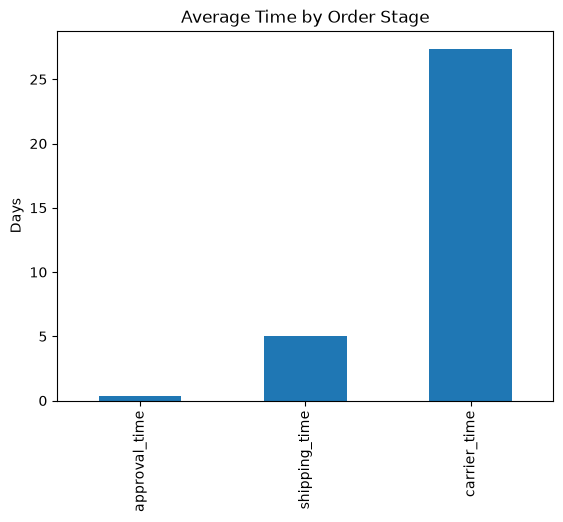

In [13]:
late_orders[['approval_time', 'shipping_time', 'carrier_time']].mean().plot(kind='bar')

plt.title('Average Time by Order Stage')
plt.ylabel('Days')
plt.show()

## Seller Performance by State

In [14]:
df_seller=orders.merge(order_items, on='order_id', how='left') \
           .merge(sellers, on='seller_id', how='left')

In [15]:
seller_state_performance = (
    df_seller.groupby('seller_state')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('delay', lambda x: (x > 0).sum()),
        on_time_orders=('delay', lambda x: (x <= 0).sum())
    )
)

In [16]:
seller_state_performance['late_rate'] = (
    seller_state_performance['late_orders']
    / seller_state_performance['total_orders']
) * 100


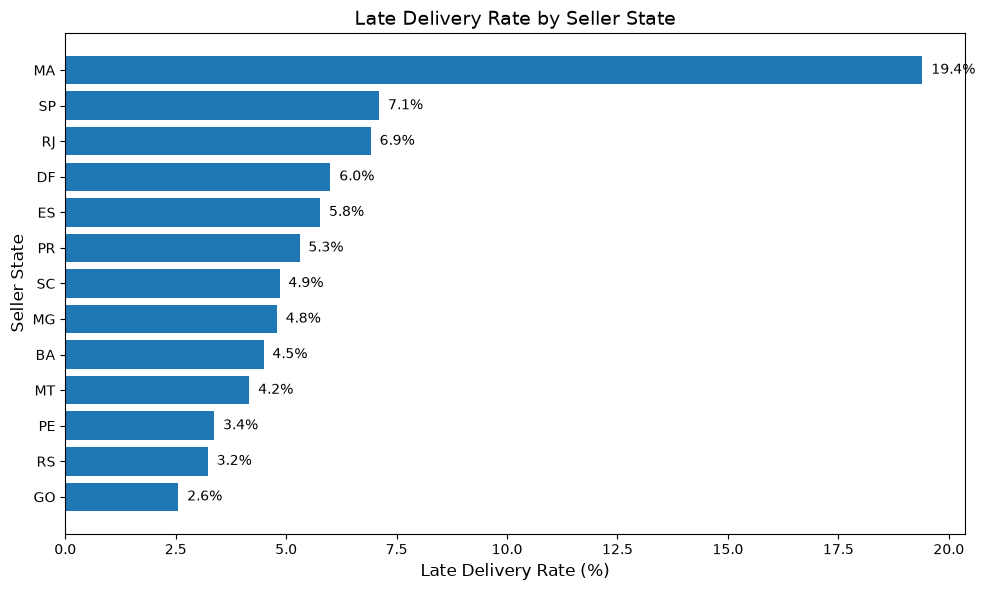

In [17]:
# Filter states with more than 100 orders
plot_data = (
    seller_state_performance[seller_state_performance['total_orders'] > 100]
    .sort_values(by='late_rate', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(plot_data.index, plot_data['late_rate'])

plt.title("Late Delivery Rate by Seller State", fontsize=14)
plt.xlabel("Late Delivery Rate (%)", fontsize=12)
plt.ylabel("Seller State", fontsize=12)

# Display values on bars
for i, value in enumerate(plot_data['late_rate']):
    plt.text(value + 0.2, i, f"{value:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
plot_data

,total_orders,late_orders,on_time_orders,late_rate
seller_state,,,,
GO,508,13,495,2.559055
RS,2169,70,2099,3.227294
PE,445,15,430,3.370787
MT,144,6,138,4.166667
BA,624,28,596,4.487179
MG,8603,412,8189,4.789027
SC,4000,194,3806,4.850000
PR,8487,450,8037,5.302227
ES,364,21,343,5.769231


Top Sellers with Highest Late Delivery Rate

In [19]:
df_unique = (
    df_seller
    .groupby(['seller_id', 'seller_state', 'order_id'], as_index=False)
    .agg(delay=('delay', 'max'))
)

In [20]:
seller_performance = (
    df_unique.groupby('seller_id')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('delay', lambda x: (x > 0).sum()),
        on_time_orders=('delay', lambda x: (x <= 0).sum())
    )
)

In [21]:
seller_performance['late_rate'] = (
    seller_performance['late_orders']
    / seller_performance['total_orders']
) * 100

In [22]:
top_sellers = (
    seller_performance[seller_performance['total_orders'] > 100]
    .sort_values(by='late_rate', ascending=False)
    .head(10)
    .sort_values(by='late_rate', ascending=False)
)
top_sellers

,total_orders,late_orders,on_time_orders,late_rate
seller_id,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,389,74,315,19.023136
88460e8ebdecbfecb5f9601833981930,246,42,204,17.073171
1ca7077d890b907f89be8c954a02686a,108,18,90,16.666667
e5a3438891c0bfdb9394643f95273d8e,216,34,182,15.740741
cd68562d3f44870c08922d380acae552,122,19,103,15.573770
2c9e548be18521d1c43cde1c582c6de8,124,19,105,15.322581
431af27f296bc6519d890aa5a05fdb11,116,16,100,13.793103
f7ba60f8c3f99e7ee4042fdef03b70c4,218,30,188,13.761468
8160255418d5aaa7dbdc9f4c64ebda44,380,52,328,13.684211


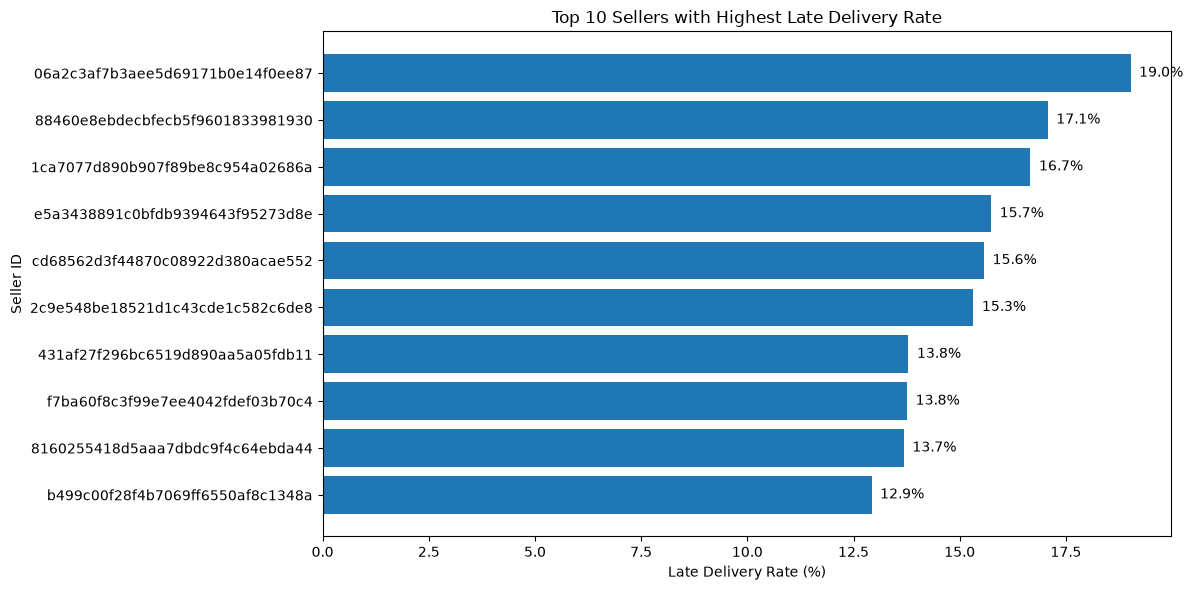

In [23]:

# Top sellers (minimum 100 orders)
top_sellers = (
    seller_performance[seller_performance['total_orders'] > 100]
    .sort_values(by='late_rate', ascending=False)
    .head(10)
    .sort_values(by='late_rate', ascending=True)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_sellers.index.astype(str),
    top_sellers['late_rate']
)

plt.title("Top 10 Sellers with Highest Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")

# Show percentage on each bar
for i, value in enumerate(top_sellers['late_rate']):
    plt.text(value + 0.2, i, f"{value:.1f}%", va='center')

plt.tight_layout()
plt.show()

## Relationship Between Seller Order Volume and Late Delivery Rate

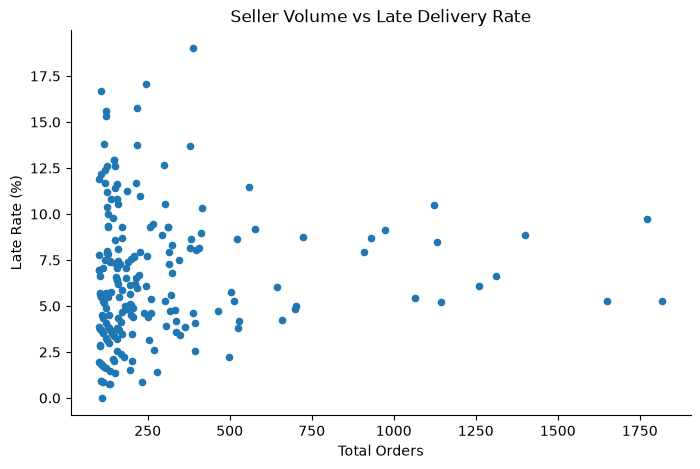

In [24]:
ax = seller_performance[
    seller_performance['total_orders'] > 100
].plot(
    kind='scatter',
    x='total_orders',
    y='late_rate',
    figsize=(8,5)
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Total Orders')
plt.ylabel('Late Rate (%)')
plt.title('Seller Volume vs Late Delivery Rate')
plt.show()

## Relationship Between Freight Cost and Delivery Delay


In [25]:
df_fight_value=late_orders.merge(order_items, on='order_id', how='left') 

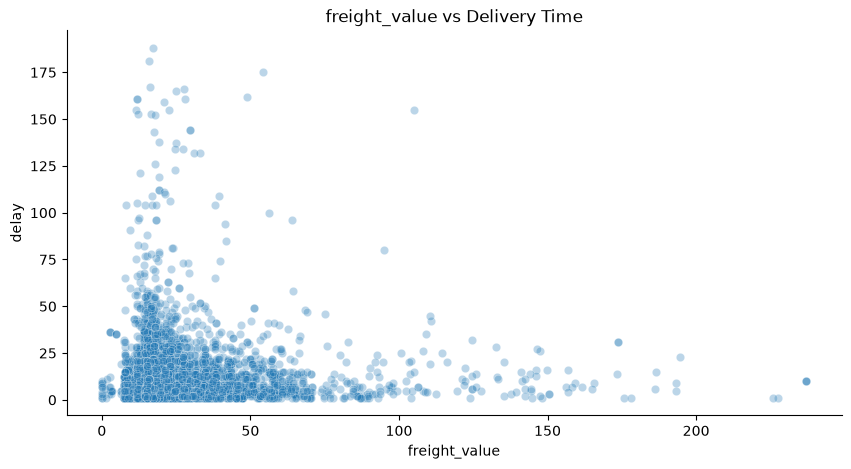

In [26]:
# • Are expensive shipments actually faster?
plt.figure(figsize=(10,5), dpi=100)
sns.scatterplot(x='freight_value', y='delay', data=df_fight_value,alpha=0.3)
plt.title("freight_value vs Delivery Time")
plt.gcf().patch.set_alpha(0)  
plt.gca().patch.set_alpha(0)  
sns.despine()
plt.savefig("freight_vs_delay.pdf", bbox_inches='tight')
plt.show()


##  Impact of Delivery Performance on Customer Satisfaction

In [27]:
avg_review_per_order = (
    reviews.groupby('order_id')['review_score']
    .mean()
    .reset_index(name='avg_review_score')
)

In [28]:
df_review=orders.merge(    
    avg_review_per_order,
    on='order_id',
    how='left') 

In [29]:
df_review['delivery_status'] = df_review['delay'].apply(
    lambda x: 'Delayed' if x > 0 else 'On Time'
)

review_comparison=df_review.groupby('delivery_status')['avg_review_score'].mean()
print(review_comparison)

delivery_status
Delayed    2.271823
On Time    4.290608
Name: avg_review_score, dtype: float64


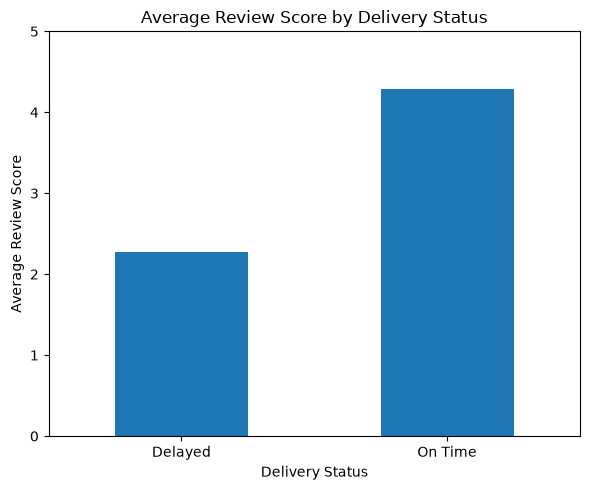

In [30]:
plt.figure(figsize=(6,5))

review_comparison.plot(
    kind='bar',
    rot=0
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.ylim(0,5)

plt.tight_layout()
plt.show()

In [31]:
rating_drop = (
    review_comparison['On Time']
    - review_comparison['Delayed']
)

print(f'Rating drop: {rating_drop:.2f} stars')

Rating drop: 2.02 stars
